<a href="https://colab.research.google.com/github/stacykeago/fundamentals-of-data-analytics/blob/main/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np

In [23]:
dia= pd.read_csv('/content/diabetes.csv')
dia.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming 'dia' DataFrame is already loaded (from previous steps)
# If 'dia' is not loaded, uncomment and run the following line:
# dia = pd.read_csv('/content/diabetes.csv')

# 1. Separate features (X) and target (y)
X = dia.drop('Outcome', axis=1)
y = dia['Outcome']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# 3. Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) # Using 100 trees as a default
rf_model.fit(X_train, y_train)

print("\nRandom Forest Classifier trained successfully.")

# 4. Make predictions and evaluate the model
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)


Features (X) shape: (768, 8)
Target (y) shape: (768,)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)

Random Forest Classifier trained successfully.

Model Accuracy: 0.7208

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154


Confusion Matrix:
[[77 22]
 [21 34]]


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150, 200], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Initialize a RandomForestClassifier for tuning
# Using the same random_state for reproducibility
rf_model_tuned = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model_tuned,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=2, # Be verbose about the process
    scoring='accuracy' # Optimize for accuracy
)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV for hyperparameter tuning...")
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

# Get the best estimator (model) and best parameters
best_rf_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest Parameters found: {best_params}")
print(f"Best Cross-validation Accuracy (on training data): {best_score:.4f}")

# Make predictions with the best model on the test set
y_pred_tuned = best_rf_model.predict(X_test)

# Evaluate the best model on the test set
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"\nTest Set Accuracy (with best model): {accuracy_tuned:.4f}")
print("\nClassification Report (with best model):")
print(report_tuned)
print("\nConfusion Matrix (with best model):")
print(conf_matrix_tuned)


Starting GridSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
GridSearchCV completed.

Best Parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-validation Accuracy (on training data): 0.7834

Test Set Accuracy (with best model): 0.7338

Classification Report (with best model):
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        99
           1       0.62      0.65      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.74       154


Confusion Matrix (with best model):
[[77 22]
 [19 36]]


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize a RandomForestClassifier with the specified parameters
# Assuming X_train, X_test, y_train, y_test are already defined from previous steps
rf_custom_model = RandomForestClassifier(n_estimators=75, max_depth=4, random_state=42)

# Train the model
rf_custom_model.fit(X_train, y_train)

print("Random Forest Classifier trained with max_depth=4 and n_estimators=75.")

# Make predictions on the test set
y_pred_custom = rf_custom_model.predict(X_test)

# Evaluate the model
accuracy_custom = accuracy_score(y_test, y_pred_custom)
report_custom = classification_report(y_test, y_pred_custom)
conf_matrix_custom = confusion_matrix(y_test, y_pred_custom)

print(f"\nModel Accuracy (max_depth=4, n_estimators=75): {accuracy_custom:.4f}")
print("\nClassification Report:")
print(report_custom)
print("\nConfusion Matrix:")
print(conf_matrix_custom)


Random Forest Classifier trained with max_depth=4 and n_estimators=75.

Model Accuracy (max_depth=4, n_estimators=75): 0.7987

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        99
           1       0.76      0.64      0.69        55

    accuracy                           0.80       154
   macro avg       0.79      0.76      0.77       154
weighted avg       0.80      0.80      0.79       154


Confusion Matrix:
[[88 11]
 [20 35]]


In [27]:
from sklearn.metrics import roc_auc_score

# Calculate probability predictions using the best_rf_model from GridSearchCV
Y_pred_prob = best_rf_model.predict_proba(X_test)

# Display the probability predictions
Y_pred_prob

array([[0.48356746, 0.51643254],
       [0.71455952, 0.28544048],
       [0.85016667, 0.14983333],
       [0.75419048, 0.24580952],
       [0.52309127, 0.47690873],
       [0.42400794, 0.57599206],
       [0.975     , 0.025     ],
       [0.30182143, 0.69817857],
       [0.4334881 , 0.5665119 ],
       [0.36929762, 0.63070238],
       [0.84626984, 0.15373016],
       [0.17405556, 0.82594444],
       [0.74141667, 0.25858333],
       [0.63165476, 0.36834524],
       [0.95666667, 0.04333333],
       [0.63411905, 0.36588095],
       [0.8597381 , 0.1402619 ],
       [0.9825    , 0.0175    ],
       [0.50191667, 0.49808333],
       [0.57390476, 0.42609524],
       [0.52467749, 0.47532251],
       [0.90928571, 0.09071429],
       [0.6803254 , 0.3196746 ],
       [0.996     , 0.004     ],
       [0.42450397, 0.57549603],
       [0.12092857, 0.87907143],
       [0.96066667, 0.03933333],
       [0.97733333, 0.02266667],
       [0.89177381, 0.10822619],
       [0.89535714, 0.10464286],
       [0.

AUC-ROC Score: 0.8116


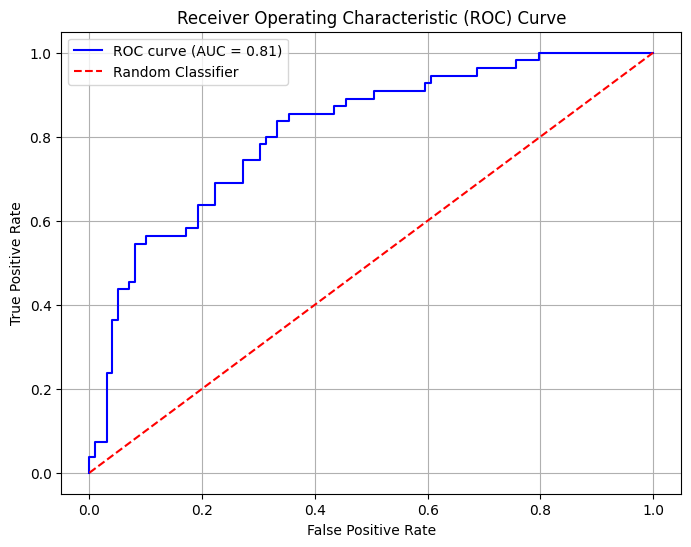

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate FPR, TPR, and thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, Y_pred_prob[:, 1])

# Calculate the Area Under the Receiver Operating Characteristic Curve (AUC-ROC)
auc_roc = roc_auc_score(y_test, Y_pred_prob[:, 1])

print(f"AUC-ROC Score: {auc_roc:.4f}")

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_roc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()